# Exploring Synthetic QA Dataset

This notebook explores the generation of synthetic conversational Question Answering templates. We will analyze the length distribution of food entities and visualize the sentence length (token counts) of the generated synthetic dataset.

In [1]:
import os
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original food base to extract foods
food_path = '../../data/en/food_bio.jsonl'
if not os.path.exists(food_path):
    food_path = 'data/en/food_bio.jsonl'

food_rows = []
with open(food_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            food_rows.append(json.loads(line))

print(f"Loaded {len(food_rows)} food base rows.")

Loaded 800 food base rows.


## 1. Extract Unique Food Entities & Analyze Token Lengths

In [2]:
unique_foods = set()
for r in food_rows:
    tokens = r["tokens"]
    labels = r["labels"]
    current_food = []
    for t, l in zip(tokens, labels):
        if l == "B-FOOD":
            if current_food:
                unique_foods.add(tuple(current_food))
            current_food = [t]
        elif l == "I-FOOD":
            if current_food:
                current_food.append(t)
        else:
            if current_food:
                unique_foods.add(tuple(current_food))
                current_food = []
    if current_food:
        unique_foods.add(tuple(current_food))

print(f"Extracted {len(unique_foods)} unique food entity token lists.")

Extracted 1860 unique food entity token lists.


## 2. Simulate Synthetic QA Template Generation

In [3]:
synthetic_rows = []

for food_tuple in unique_foods:
    food_tokens = list(food_tuple)
    food_len = len(food_tokens)
    food_labels = ["B-FOOD"] + ["I-FOOD"] * (food_len - 1)
    
    # T1: What is the nutrition values of [FOOD]?
    synthetic_rows.append({
        "template": "T1 (What is the nutrition values of [FOOD]?)",
        "tokens": ["What", "is", "the", "nutrition", "values", "of"] + food_tokens + ["?"],
        "labels": ["O", "O", "O", "O", "O", "O"] + food_labels + ["O"]
    })
    # T2: Show me the protein in [FOOD]
    synthetic_rows.append({
        "template": "T2 (Show me the protein in [FOOD])",
        "tokens": ["Show", "me", "the", "protein", "in"] + food_tokens,
        "labels": ["O", "O", "O", "B-NUTRIENT", "O"] + food_labels
    })
    # T3: How many calories are in [FOOD]?
    synthetic_rows.append({
        "template": "T3 (How many calories are in [FOOD]?)",
        "tokens": ["How", "many", "calories", "are", "in"] + food_tokens + ["?"],
        "labels": ["O", "O", "B-NUTRIENT", "O", "O"] + food_labels + ["O"]
    })
    # T4: what about [FOOD]?
    synthetic_rows.append({
        "template": "T4 (what about [FOOD]?)",
        "tokens": ["what", "about"] + food_tokens + ["?"],
        "labels": ["O", "O"] + food_labels + ["O"]
    })
    # T5: Is [FOOD] good for diabetes?
    synthetic_rows.append({
        "template": "T5 (Is [FOOD] good for diabetes?)",
        "tokens": ["Is"] + food_tokens + ["good", "for", "diabetes", "?"],
        "labels": ["O"] + food_labels + ["O", "O", "B-DISEASE", "O"]
    })
    # T6: Tell me about [FOOD]
    synthetic_rows.append({
        "template": "T6 (Tell me about [FOOD])",
        "tokens": ["Tell", "me", "about"] + food_tokens,
        "labels": ["O", "O", "O"] + food_labels
    })

print(f"Generated {len(synthetic_rows)} synthetic QA rows from {len(unique_foods)} foods across 6 templates.")

Generated 11160 synthetic QA rows from 1860 foods across 6 templates.


## 3. Visualizations

C:\Users\dongb\AppData\Local\Temp\ipykernel_25612\3843190024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(len_counter.keys()), y=list(len_counter.values()), palette="Purples_r")


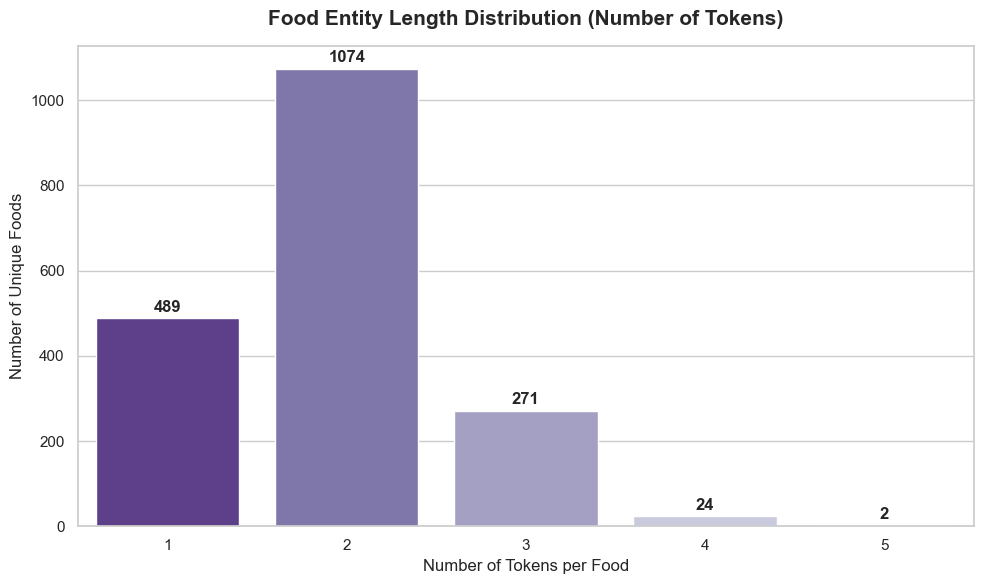

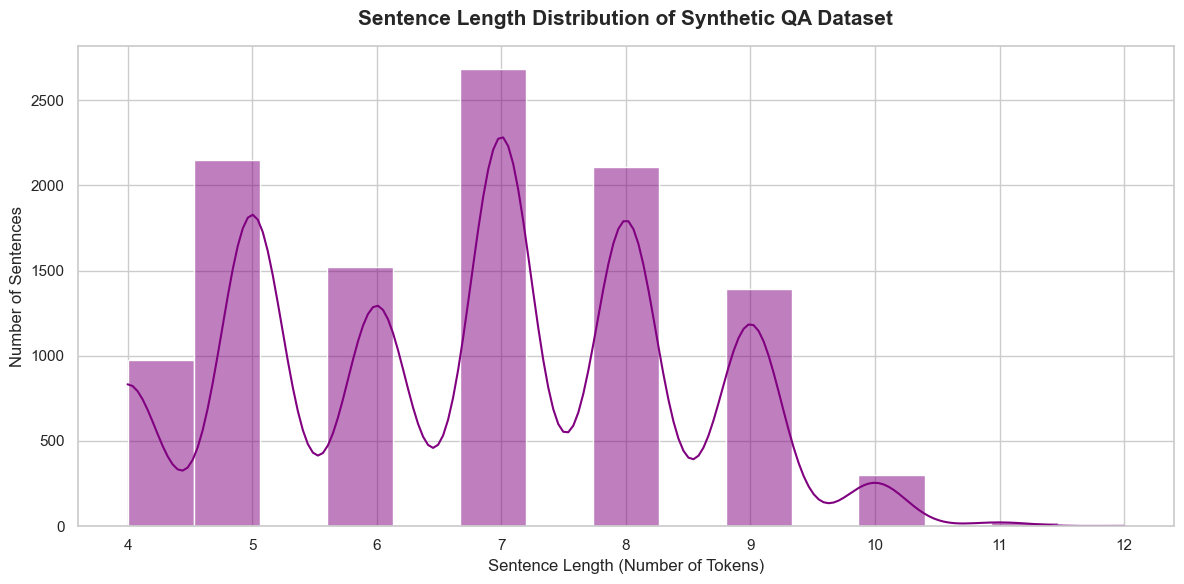

In [4]:
sns.set_theme(style="whitegrid")

# 1. Plot Food Entity Token Length Distribution
food_lengths = [len(f) for f in unique_foods]
len_counter = Counter(food_lengths)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(len_counter.keys()), y=list(len_counter.values()), palette="Purples_r")
plt.title("Food Entity Length Distribution (Number of Tokens)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of Tokens per Food", fontsize=12)
plt.ylabel("Number of Unique Foods", fontsize=12)
for x, y in len_counter.items():
    plt.text(x - 1, y + 15, str(y), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Plot Sentence Length Distribution of Generated Dataset
sent_lengths = [len(r['tokens']) for r in synthetic_rows]

plt.figure(figsize=(12, 6))
sns.histplot(sent_lengths, bins=15, kde=True, color="purple")
plt.title("Sentence Length Distribution of Synthetic QA Dataset", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Sentence Length (Number of Tokens)", fontsize=12)
plt.ylabel("Number of Sentences", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Review Generated Samples by Template

In [5]:
samples_by_template = {}
for r in synthetic_rows:
    t_name = r['template']
    if t_name not in samples_by_template:
        samples_by_template[t_name] = []
    samples_by_template[t_name].append(r)

for t_name, rows_list in sorted(samples_by_template.items()):
    print(f"\n=== Template: {t_name} ===")
    print(f"Total generated sentences: {len(rows_list)}")
    print("Example sentences:")
    for sample in rows_list[:2]:
        formatted = [f"{tok}[{lbl}]" if lbl != 'O' else tok for tok, lbl in zip(sample['tokens'], sample['labels'])]
        print("  -", " ".join(formatted))


=== Template: T1 (What is the nutrition values of [FOOD]?) ===
Total generated sentences: 1860
Example sentences:
  - What is the nutrition values of olive[B-FOOD] brine[I-FOOD] ?
  - What is the nutrition values of mayonnaise[B-FOOD] mixture[I-FOOD] ?

=== Template: T2 (Show me the protein in [FOOD]) ===
Total generated sentences: 1860
Example sentences:
  - Show me the protein[B-NUTRIENT] in olive[B-FOOD] brine[I-FOOD]
  - Show me the protein[B-NUTRIENT] in mayonnaise[B-FOOD] mixture[I-FOOD]

=== Template: T3 (How many calories are in [FOOD]?) ===
Total generated sentences: 1860
Example sentences:
  - How many calories[B-NUTRIENT] are in olive[B-FOOD] brine[I-FOOD] ?
  - How many calories[B-NUTRIENT] are in mayonnaise[B-FOOD] mixture[I-FOOD] ?

=== Template: T4 (what about [FOOD]?) ===
Total generated sentences: 1860
Example sentences:
  - what about olive[B-FOOD] brine[I-FOOD] ?
  - what about mayonnaise[B-FOOD] mixture[I-FOOD] ?

=== Template: T5 (Is [FOOD] good for diabetes?) ===